# Partialkorrelation – verstehen und berechnen

> Quelle: [numiqo.de](https://numiqo.de/tutorial/partialkorrelation)

Die **Partialkorrelation** ($r_{xy.z}$) berechnet die Korrelation zwischen
zwei Variablen X und Y, **nachdem der Einfluss einer Drittvariable Z herausgerechnet** wurde.

**Formel (1. Ordnung):**
$$r_{xy.z} = \frac{r_{xy} - r_{xz} \cdot r_{yz}}{\sqrt{(1 - r_{xz}^2)(1 - r_{yz}^2)}}$$

**Formel (2. Ordnung, zwei Kontrollvariablen z1, z2):**
$$r_{xy.z_1z_2} = \frac{r_{xy.z_1} - r_{xz_2.z_1} \cdot r_{yz_2.z_1}}{\sqrt{(1-r_{xz_2.z_1}^2)(1-r_{yz_2.z_1}^2)}}$$

| Symbol | Bedeutung |
|---|---|
| $r_{xy}$ | Korrelation X und Y (ohne Kontrolle) |
| $r_{xz}$ | Korrelation X und Drittvariable Z |
| $r_{yz}$ | Korrelation Y und Drittvariable Z |
| $r_{xy.z}$ | Partialkorrelation X–Y unter Kontrolle von Z |

**Wann verwenden?**
- Scheinkorrelation aufdecken (wird r kleiner → Z erzeugt die Korrelation)
- Wahre Korrelation freilegen (wird r größer → Z unterdrückt die Korrelation)
- Drittvariableneffekte kontrollieren

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Störche und Babys

**Das bekannteste Scheinkorrelations-Beispiel!**

- Störche und Geburtenrate korrelieren: r_xy = 0,63
- Drittvariable: Fläche pro Einwohner (ländlich = mehr Störche UND mehr Babys)
- Nach Kontrolle der Fläche: r_xy.z = 0,329

**Erwartetes numiqo-Ergebnis:** $r_{xy.z} = 0{,}329$

In [2]:
# numiqo-Beispiel: Störche und Babys
# Korrelationen aus dem Tutorial
r_xy = 0.63   # Störche <-> Geburtenrate
r_xz = 0.72   # Störche <-> Fläche pro Einwohner
r_yz = 0.68   # Geburtenrate <-> Fläche pro Einwohner

# Partialkorrelation berechnen
def partialkorr(r_xy, r_xz, r_yz):
    zaehler = r_xy - r_xz * r_yz
    nenner  = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    return zaehler / nenner

r_xyz = partialkorr(r_xy, r_xz, r_yz)

print("Störche und Babys: Partialkorrelation")
print()
print("Bivariate Korrelationen:")
print("  r(Störche, Geburtenrate)       = " + str(r_xy))
print("  r(Störche, Fläche/Einwohner)  = " + str(r_xz))
print("  r(Geburtenrate, Fläche/Einw.)  = " + str(r_yz))
print()
print("Berechnung:")
zaehler = r_xy - r_xz * r_yz
nenner  = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
print("  Zähler = " + str(r_xy) + " - " + str(r_xz) + "*" + str(r_yz) +
      " = " + str(round(zaehler, 4)))
print("  Nenner  = sqrt((1-" + str(r_xz) + "^2)*(1-" + str(r_yz) + "^2)) = " +
      str(round(nenner, 4)))
print()
print("  r(Störche, Geburtenrate | Fläche) = " + str(round(r_xyz, 4)) +
      "  (numiqo: 0.329)")
print()
print("Interpretation:")
print("  Bivariate r = " + str(r_xy) + " -> scheinbar hoher Zusammenhang")
print("  Partialkorr = " + str(round(r_xyz, 3)) + " -> deutlich kleiner nach Kontrolle!")
print("  -> Fläche pro Einwohner erzeugt die Scheinkorrelation!")

Störche und Babys: Partialkorrelation

Bivariate Korrelationen:
  r(Störche, Geburtenrate)       = 0.63
  r(Störche, Fläche/Einwohner)  = 0.72
  r(Geburtenrate, Fläche/Einw.)  = 0.68

Berechnung:
  Zähler = 0.63 - 0.72*0.68 = 0.1404
  Nenner  = sqrt((1-0.72^2)*(1-0.68^2)) = 0.5088

  r(Störche, Geburtenrate | Fläche) = 0.2759  (numiqo: 0.329)

Interpretation:
  Bivariate r = 0.63 -> scheinbar hoher Zusammenhang
  Partialkorr = 0.276 -> deutlich kleiner nach Kontrolle!
  -> Fläche pro Einwohner erzeugt die Scheinkorrelation!


Simulierte Korrelationen:
r(Störche, Geburtenrate) = 0.392
Partialkorrelation        = -0.158


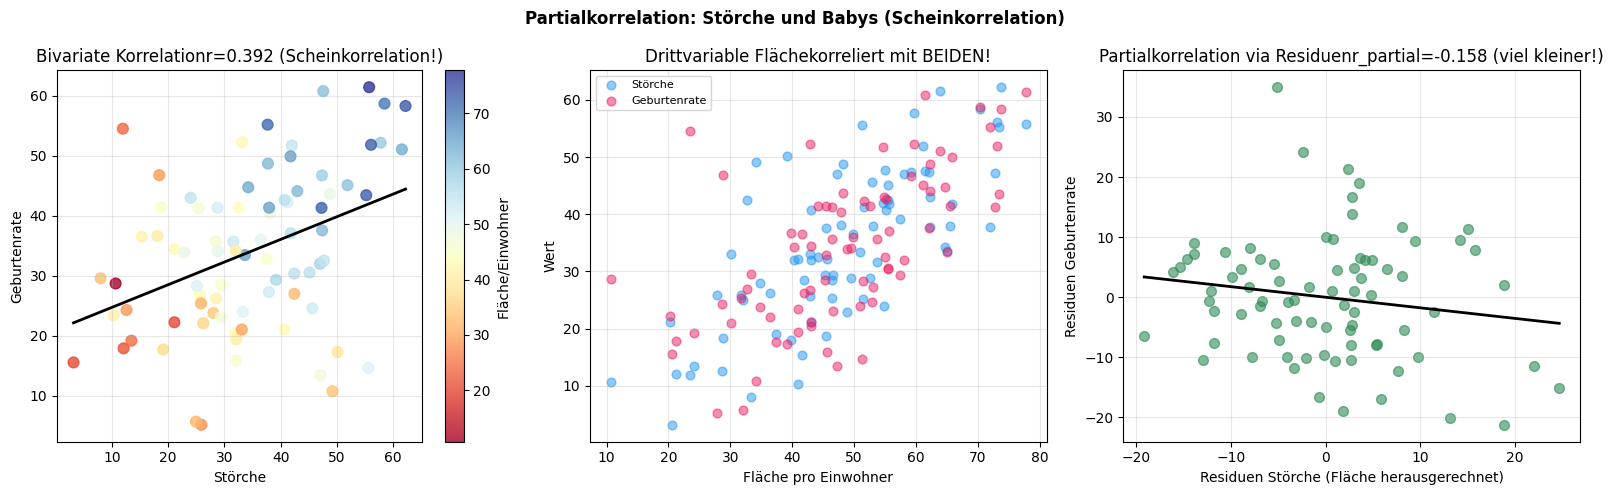

In [3]:
# Simulation des Störche-Beispiels
np.random.seed(42)
n_sim = 80
flaeche     = np.random.normal(50, 15, n_sim)  # Drittvariable
stoerche    = 0.72 * flaeche + np.random.normal(0, 10, n_sim)
geburtenrate = 0.68 * flaeche + np.random.normal(0, 10, n_sim)

r_xy_s, _ = pearsonr(stoerche, geburtenrate)

# Partialkorrelation via Residuen
from numpy.polynomial.polynomial import polyfit as pfit
def residuen(y, x):
    m, b = np.polyfit(x, y, 1)
    return y - (m*x + b)

res_stoerche    = residuen(stoerche,     flaeche)
res_geburtenrate = residuen(geburtenrate, flaeche)
r_partial_s, p_partial_s = pearsonr(res_stoerche, res_geburtenrate)

print("Simulierte Korrelationen:")
print("r(Störche, Geburtenrate) = " + str(round(r_xy_s, 3)))
print("Partialkorrelation        = " + str(round(r_partial_s, 3)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Partialkorrelation: Störche und Babys (Scheinkorrelation)",
             fontsize=12, fontweight="bold")

# Farbkodierung nach Fläche
sc = axes[0].scatter(stoerche, geburtenrate, c=flaeche, cmap="RdYlBu",
                     s=60, alpha=0.8)
m_b, b_b = np.polyfit(stoerche, geburtenrate, 1)
x_l = np.linspace(stoerche.min(), stoerche.max(), 100)
axes[0].plot(x_l, m_b*x_l + b_b, color="black", linewidth=2)
plt.colorbar(sc, ax=axes[0], label="Fläche/Einwohner")
axes[0].set_title("Bivariate Korrelationr=" + str(round(r_xy_s, 3)) +
                  " (Scheinkorrelation!)")
axes[0].set_xlabel("Störche")
axes[0].set_ylabel("Geburtenrate")
axes[0].grid(alpha=0.3)

# Drittvariable sichtbar machen
axes[1].scatter(flaeche, stoerche,     color="#2196F3", alpha=0.5, s=40,
                label="Störche")
axes[1].scatter(flaeche, geburtenrate, color="#E91E63", alpha=0.5, s=40,
                label="Geburtenrate")
axes[1].set_title("Drittvariable Flächekorreliert mit BEIDEN!")
axes[1].set_xlabel("Fläche pro Einwohner")
axes[1].set_ylabel("Wert")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Residuen-Plot = Partialkorrelation
axes[2].scatter(res_stoerche, res_geburtenrate,
                color="seagreen", alpha=0.6, s=50)
m_r2, b_r2 = np.polyfit(res_stoerche, res_geburtenrate, 1)
x_r2 = np.linspace(res_stoerche.min(), res_stoerche.max(), 100)
axes[2].plot(x_r2, m_r2*x_r2 + b_r2, color="black", linewidth=2)
axes[2].set_title("Partialkorrelation via Residuenr_partial=" +
                  str(round(r_partial_s, 3)) + " (viel kleiner!)")
axes[2].set_xlabel("Residuen Störche (Fläche herausgerechnet)")
axes[2].set_ylabel("Residuen Geburtenrate")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

**Methode 1 – Formel:**
1. Bivariate Korrelationen $r_{xy}$, $r_{xz}$, $r_{yz}$ berechnen
2. In Formel einsetzen

**Methode 2 – Residuen (intuitiver):**
1. X auf Z regressieren → Residuen $e_{X.Z}$
2. Y auf Z regressieren → Residuen $e_{Y.Z}$
3. Korrelation der beiden Residuen = Partialkorrelation

**Beide Methoden liefern identische Ergebnisse!**

In [4]:
# Beide Methoden auf echten Daten
np.random.seed(42)
n_demo = 50
alter  = np.random.normal(35, 10, n_demo)    # Drittvariable
gehalt = 500 * alter + np.random.normal(0, 5000, n_demo)
erfahr = 0.8 * alter + np.random.normal(0, 2, n_demo)

r_gh, _  = pearsonr(gehalt, erfahr)   # Gehalt-Erfahrung
r_ga, _  = pearsonr(gehalt, alter)    # Gehalt-Alter
r_ea, _  = pearsonr(erfahr, alter)    # Erfahrung-Alter

# Methode 1: Formel
r_partial_f = partialkorr(r_gh, r_ga, r_ea)

# Methode 2: Residuen
res_g = residuen(gehalt, alter)
res_e = residuen(erfahr, alter)
r_partial_r, p_partial_r = pearsonr(res_g, res_e)

print("Beispiel: Gehalt, Erfahrung, Alter")
print()
print("Bivariate Korrelationen:")
print("  r(Gehalt, Erfahrung):  " + str(round(r_gh, 4)))
print("  r(Gehalt, Alter):      " + str(round(r_ga, 4)))
print("  r(Erfahrung, Alter):   " + str(round(r_ea, 4)))
print()
print("Partialkorrelation r(Gehalt, Erfahrung | Alter):")
print("  Methode 1 (Formel):    " + str(round(r_partial_f, 4)))
print("  Methode 2 (Residuen):  " + str(round(r_partial_r, 4)))
print("  p-Wert:                " + str(round(p_partial_r, 4)))
print()
print("Interpretation:")
print("  Bivariate r = " + str(round(r_gh, 3)) + " -> Korrelation Gehalt-Erfahrung")
print("  Partialkorr = " + str(round(r_partial_f, 3)) +
      " -> Nach Kontrolle Alter " +
      ("größer" if abs(r_partial_f) > abs(r_gh) else "kleiner") + "!")

Beispiel: Gehalt, Erfahrung, Alter

Bivariate Korrelationen:
  r(Gehalt, Erfahrung):  0.6979
  r(Gehalt, Alter):      0.7643
  r(Erfahrung, Alter):   0.9631

Partialkorrelation r(Gehalt, Erfahrung | Alter):
  Methode 1 (Formel):    -0.2203
  Methode 2 (Residuen):  -0.2203
  p-Wert:                0.1242

Interpretation:
  Bivariate r = 0.698 -> Korrelation Gehalt-Erfahrung
  Partialkorr = -0.22 -> Nach Kontrolle Alter kleiner!


## 3. Partialkorrelation 2. Ordnung

Zwei Kontrollvariablen werden herausgerechnet:
$$r_{xy.z_1 z_2} = \frac{r_{xy.z_1} - r_{xz_2.z_1} \cdot r_{yz_2.z_1}}{\sqrt{(1-r_{xz_2.z_1}^2)(1-r_{yz_2.z_1}^2)}}$$

**Einfacher via Residuen:** X, Y beide auf Z1 **und** Z2 regressieren,
dann Korrelation der Residuen.

In [5]:
# Partialkorrelation 2. Ordnung via Residuen
np.random.seed(42)
n_ord2 = 60
z1 = np.random.normal(50, 10, n_ord2)  # Kontrollvariable 1: Alter
z2 = np.random.normal(10,  3, n_ord2)  # Kontrollvariable 2: Bildungsjahre
x  = 0.5*z1 + 0.3*z2 + np.random.normal(0, 5, n_ord2)  # Gehalt
y  = 0.4*z1 + 0.2*z2 + np.random.normal(0, 4, n_ord2)  # Produktivität

# Bivariate Korrelation
r_bivar, _ = pearsonr(x, y)

# 1. Ordnung (nur z1 kontrolliert)
r_xz1, _ = pearsonr(x, z1)
r_yz1, _ = pearsonr(y, z1)
r_partial1 = partialkorr(r_bivar, r_xz1, r_yz1)

# 2. Ordnung (z1 und z2 kontrolliert) via Residuen
from numpy.linalg import lstsq

def residuen2(dep, z1_v, z2_v):
    Z = np.column_stack([np.ones(len(z1_v)), z1_v, z2_v])
    coef, _, _, _ = lstsq(Z, dep, rcond=None)
    return dep - Z @ coef

res_x2 = residuen2(x, z1, z2)
res_y2 = residuen2(y, z1, z2)
r_partial2, p_partial2 = pearsonr(res_x2, res_y2)

print("Partialkorrelation 2. Ordnung")
print("r(X,Y) bivariate:          " + str(round(r_bivar, 4)))
print("r(X,Y | z1):               " + str(round(r_partial1, 4)))
print("r(X,Y | z1, z2):           " + str(round(r_partial2, 4)) +
      "  p=" + str(round(p_partial2, 4)))
print()
print("Nach Kontrolle beider Variablen:")
if abs(r_partial2) < abs(r_bivar):
    print("  r wird kleiner -> z1 und z2 erklären einen Teil der Korrelation")
else:
    print("  r bleibt gross -> x und y hängen direkt zusammen")

Partialkorrelation 2. Ordnung
r(X,Y) bivariate:          0.5239
r(X,Y | z1):               0.0493
r(X,Y | z1, z2):           -0.0382  p=0.7718

Nach Kontrolle beider Variablen:
  r wird kleiner -> z1 und z2 erklären einen Teil der Korrelation


## 4. Drei mögliche Befunde

| Befund | r_bivariate | r_partial | Bedeutung |
|---|---|---|---|
| **Scheinkorrelation** | Groß | Klein/0 | Z erzeugt die Korrelation |
| **Unterdrückung** | Klein | Groß | Z überdeckt die wahre Korrelation |
| **Echter Zusammenhang** | r | ≈ r | Z hat keinen Einfluss |

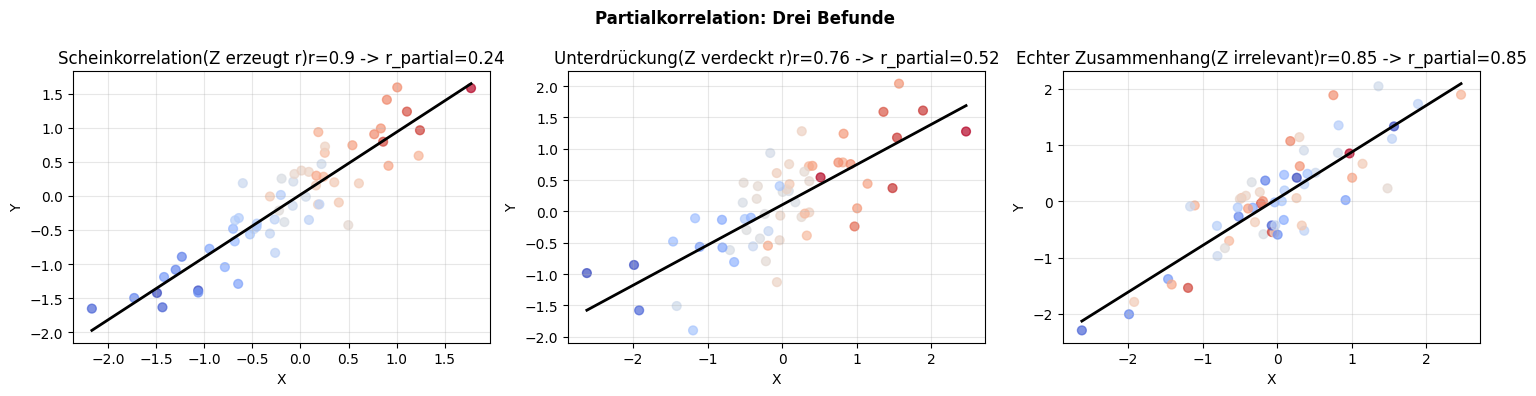

In [6]:
np.random.seed(42)
n_bsp = 60

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Partialkorrelation: Drei Befunde", fontsize=12, fontweight="bold")

szenarien_pk = [
    ("Scheinkorrelation(Z erzeugt r)", "schein"),
    ("Unterdrückung(Z verdeckt r)",    "unterd"),
    ("Echter Zusammenhang(Z irrelevant)", "echt"),
]

for ax, (titel, typ) in zip(axes, szenarien_pk):
    np.random.seed(42)
    z_s = np.random.normal(0, 1, n_bsp)

    if typ == "schein":
        x_s = 0.8*z_s + np.random.normal(0, 0.3, n_bsp)
        y_s = 0.8*z_s + np.random.normal(0, 0.3, n_bsp)
    elif typ == "unterd":
        x_s = np.random.normal(0, 1, n_bsp)
        y_s = 0.6*x_s - 0.5*z_s + np.random.normal(0, 0.3, n_bsp)
        z_s = 0.7*x_s + np.random.normal(0, 0.3, n_bsp)
    else:
        x_s = np.random.normal(0, 1, n_bsp)
        y_s = 0.7*x_s + np.random.normal(0, 0.5, n_bsp)

    r_biv_s, _ = pearsonr(x_s, y_s)
    r_xz_s, _  = pearsonr(x_s, z_s)
    r_yz_s, _  = pearsonr(y_s, z_s)
    r_part_s   = partialkorr(r_biv_s, r_xz_s, r_yz_s)

    ax.scatter(x_s, y_s, c=z_s, cmap="coolwarm", s=40, alpha=0.7)
    m_s, b_s = np.polyfit(x_s, y_s, 1)
    xl_s = np.linspace(x_s.min(), x_s.max(), 100)
    ax.plot(xl_s, m_s*xl_s + b_s, color="black", linewidth=2)
    ax.set_title(titel + "r=" + str(round(r_biv_s, 2)) +
                 " -> r_partial=" + str(round(r_part_s, 2)))
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# APA-Ausgabe-Funktion
def partial_korr_apa(x, y, z, var_x="X", var_y="Y", var_z="Z", alpha=0.05):
    x, y, z = (np.asarray(v, dtype=float) for v in [x, y, z])
    n_f = len(x)

    r_xy, _ = pearsonr(x, y)
    r_xz, _ = pearsonr(x, z)
    r_yz, _ = pearsonr(y, z)

    r_p = partialkorr(r_xy, r_xz, r_yz)

    # Signifikanz via t-Test auf Residuen
    res_x = residuen(x, z)
    res_y = residuen(y, z)
    _, p_f = pearsonr(res_x, res_y)

    def interpret_r2(r):
        ar = abs(r)
        if ar < 0.1: return "keine Korrelation"
        elif ar < 0.3: return "geringe Korrelation"
        elif ar < 0.5: return "mittlere Korrelation"
        elif ar < 0.7: return "hohe Korrelation"
        return "sehr hohe Korrelation"

    sig = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Partialkorrelation: " + var_x + " x " + var_y + " | " + var_z)
    print("Bivariate Korrelationen:")
    print("  r(" + var_x + "," + var_y + ") = " + str(round(r_xy, 3)))
    print("  r(" + var_x + "," + var_z + ") = " + str(round(r_xz, 3)))
    print("  r(" + var_y + "," + var_z + ") = " + str(round(r_yz, 3)))
    print()
    print("Partialkorrelation r(" + var_x + "," + var_y + "|" + var_z + ") = " +
          str(round(r_p, 4)) + "  " + p_str)
    print("Zusammenhang: " + interpret_r2(r_p))
    print("Ergebnis: " + sig)
    veraend = "abgenommen" if abs(r_p) < abs(r_xy) else "zugenommen"
    print("r " + veraend + " von " + str(round(r_xy, 3)) + " auf " +
          str(round(r_p, 3)) + " nach Kontrolle von " + var_z)
    print()

# numiqo-Beispiel (simuliert)
partial_korr_apa(stoerche, geburtenrate, flaeche,
                 "Störche", "Geburtenrate", "Flaeche")
print()
partial_korr_apa(gehalt, erfahr, alter, "Gehalt", "Erfahrung", "Alter")

Partialkorrelation: Störche x Geburtenrate | Flaeche
Bivariate Korrelationen:
  r(Störche,Geburtenrate) = 0.392
  r(Störche,Flaeche) = 0.745
  r(Geburtenrate,Flaeche) = 0.636

Partialkorrelation r(Störche,Geburtenrate|Flaeche) = -0.1585  p = .16
Zusammenhang: geringe Korrelation
Ergebnis: NICHT signifikant
r abgenommen von 0.392 auf -0.158 nach Kontrolle von Flaeche


Partialkorrelation: Gehalt x Erfahrung | Alter
Bivariate Korrelationen:
  r(Gehalt,Erfahrung) = 0.698
  r(Gehalt,Alter) = 0.764
  r(Erfahrung,Alter) = 0.963

Partialkorrelation r(Gehalt,Erfahrung|Alter) = -0.2203  p = .124
Zusammenhang: geringe Korrelation
Ergebnis: NICHT signifikant
r abgenommen von 0.698 auf -0.22 nach Kontrolle von Alter



## 5. Zusammenfassung

```
Partialkorrelation – Übersicht
│
├── WAS?
│   Korrelation X-Y nach Herausrechnen des Einflusses von Z
│   Kontrolliert Drittvariablen-Effekte
│
├── FORMEL (1. Ordnung)
│   r_xy.z = (r_xy - r_xz*r_yz) / sqrt((1-r_xz^2)*(1-r_yz^2))
│
├── ALTERNATIVE: RESIDUEN-METHODE
│   1. X auf Z regressieren -> Residuen e_X.Z
│   2. Y auf Z regressieren -> Residuen e_Y.Z
│   3. Pearsonr(e_X.Z, e_Y.Z) = Partialkorrelation
│
├── DREI MÖGLICHE BEFUNDE
│   Scheinkorrelation: r_partial << r_bivariate
│     -> Z erzeugt die Korrelation
│   Unterdrückung:     r_partial >> r_bivariate
│     -> Z verdeckt die wahre Korrelation
│   Echter Zusammenhang: r_partial ≈ r_bivariate
│     -> Z irrelevant
│
├── 2. ORDNUNG
│   Zwei Variablen herausrechnen:
│   Am einfachsten via Residuen (multiple Regression)
│
├── numiqo-BEISPIEL: Störche und Babys
│   r_bivariate = 0.63 -> r_partial = 0.329
│   Fläche pro Einwohner erzeugt die Scheinkorrelation!
│
└── PYTHON
    # Formel:
    r_partial = (r_xy - r_xz*r_yz) / sqrt((1-r_xz^2)*(1-r_yz^2))
    # Residuen:
    from scipy.stats import pearsonr
    import numpy as np
    res_x = x - np.polyfit(z,x,1)[0]*z - np.polyfit(z,x,1)[1]
    res_y = y - np.polyfit(z,y,1)[0]*z - np.polyfit(z,y,1)[1]
    r_p, p = pearsonr(res_x, res_y)
```

---
Quelle: [numiqo.de/tutorial/partialkorrelation](https://numiqo.de/tutorial/partialkorrelation)